# ACS Visuals

This notebook creates ACS heatmaps, plots, rankings, change tables, and map-ready outputs.


In [1]:
from pathlib import Path
import os
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sqlalchemy import create_engine
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

## 1. Project paths and database connection

In [2]:
PROJECT_ROOT = Path.cwd()

# Try to find the real project root by walking upward until a .env is found.
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / '.env').exists():
        PROJECT_ROOT = candidate
        break

load_dotenv(PROJECT_ROOT / '.env')

DB_HOST = os.getenv('DB_HOST')
DB_PORT = os.getenv('DB_PORT')
DB_NAME = os.getenv('DB_NAME')
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')

missing_env = [
    name for name, value in {
        'DB_HOST': DB_HOST,
        'DB_PORT': DB_PORT,
        'DB_NAME': DB_NAME,
        'DB_USER': DB_USER,
        'DB_PASSWORD': DB_PASSWORD,
    }.items() if not value
]
if missing_env:
    raise ValueError(f"Missing environment variables in .env: {missing_env}")

engine = create_engine(
    f"postgresql+psycopg://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'acs' / 'analysis'
VISUALS_ROOT = OUTPUT_ROOT / 'visuals'
MAP_ROOT = OUTPUT_ROOT / 'maps'
SUMMARY_ROOT = VISUALS_ROOT / 'summary'
DATA_ROOT = VISUALS_ROOT / 'data'
PLOT_ROOT = VISUALS_ROOT / 'plots'
CHANGE_ROOT = VISUALS_ROOT / 'changes'
MAP_INPUT_ROOT = MAP_ROOT / 'map_inputs'
OPTIONAL_MAP_PLOT_ROOT = MAP_ROOT / 'optional_map_plots'

for path in [OUTPUT_ROOT, VISUALS_ROOT, MAP_ROOT, SUMMARY_ROOT, DATA_ROOT, PLOT_ROOT, CHANGE_ROOT, MAP_INPUT_ROOT, OPTIONAL_MAP_PLOT_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('VISUALS_ROOT  =', VISUALS_ROOT)
print('MAP_ROOT     =', MAP_ROOT)

PROJECT_ROOT = d:\Projects\Community-Pulse
VISUALS_ROOT  = d:\Projects\Community-Pulse\outputs\acs\analysis\visuals
MAP_ROOT     = d:\Projects\Community-Pulse\outputs\acs\analysis\maps


## 2. Pull the curated ACS tract profile table

In [3]:
QUERY = "SELECT * FROM fact_acs_tract_profile ORDER BY year, tract_geoid;"
acs = pd.read_sql(QUERY, engine)
print('Shape:', acs.shape)
acs.head(3)

Shape: (187, 70)


,year,tract_geoid,geo_id,statefp,countyfp,tractce,tract_number,tract_name_canonical,tract_name_latest,county_name,state_name,first_year_seen,last_year_seen,year_count,is_stable_all_4_years,year_label,acs_dataset,acs_period,median_household_income,median_household_income_moe,occupied_units,owner_occupied_units,renter_occupied_units,pct_owner_occupied,pct_renter_occupied,renter_hh_rent_burden_base,rent_30_34,rent_35_39,rent_40_49,rent_50_plus,rent_not_computed,pct_rent_burden_30_plus,pct_rent_burden_50_plus,pct_rent_not_computed,housing_units_total,occupied_housing_units_dp04,vacant_housing_units_dp04,pct_occupied_housing_units,pct_vacant_housing_units,for_rent_units,rented_not_occupied_units,for_sale_only_units,sold_not_occupied_units,seasonal_recreational_units,migrant_worker_units,other_vacant_units,total_population,not_hispanic_total,white_non_hispanic_population,black_non_hispanic_population,hispanic_population,pct_white_non_hispanic,pct_black_non_hispanic,pct_hispanic,has_core_housing_metrics,has_batch2_metrics,has_batch3_metrics,b19013_metrics_json,b25003_metrics_json,b25070_metrics_json,dp04_metrics_json,s1101_metrics_json,s1701_metrics_json,s1901_metrics_json,s2301_metrics_json,s1501_metrics_json,s2401_metrics_json,b03002_metrics_json,s0101_metrics_json,s1601_metrics_json
0,2019,17019000200,1400000US17019000200,17,019,000200,2,Census Tract 2,Census Tract 2; Champaign County; Illinois,Champaign County,Illinois,2019,2023,4,1,ACS 2019 5-Year,ACS5,5-Year,21385.0,4938.0,701.0,273.0,428.0,38.94,61.06,428.0,7.0,62.0,25.0,141.0,94.0,54.91,32.94,21.96,922.0,701.0,221.0,76.03,23.97,4.1,18.2,922.0,564.0,16.0,56.0,0.0,1871.0,1812.0,255.0,1403.0,59.0,13.63,74.99,3.15,1,1,1,"{'has_income_metric': 1, 'median_household_inc...","{'occupied_units': 701, 'has_tenure_metric': 1...","{'rent_30_34': 7, 'rent_35_39': 62, 'rent_40_4...","{'for_rent_units': 4.1, 'other_vacant_units': ...","{'s1101_c01_001e': 701, 's1101_c01_001m': 92, ...","{'s1701_c01_001e': 1865, 's1701_c01_001m': 315...","{'s1901_c01_001e': 701, 's1901_c01_001m': 92, ...","{'s2301_c01_001e': 1414, 's2301_c01_001m': 248...","{'s1501_c01_001e': 325, 's1501_c01_001m': 127,...","{'s2401_c01_001e': 718, 's2401_c01_001m': 168,...","{'b03002_001e': 1871, 'b03002_001m': 318, 'b03...","{'s0101_c01_001e': 1871, 's0101_c01_001m': 318...","{'s1601_c01_001e': 1699, 's1601_c01_001m': 294..."
1,2019,17019000301,1400000US17019000301,17,019,000301,3.01,Census Tract 3.01,Census Tract 3.01; Champaign County; Illinois,Champaign County,Illinois,2019,2023,4,1,ACS 2019 5-Year,ACS5,5-Year,7099.0,1978.0,2055.0,0.0,2055.0,0.00,100.00,2055.0,17.0,53.0,64.0,1157.0,591.0,62.82,56.30,28.76,2475.0,2055.0,420.0,83.03,16.97,NaN,10.6,2475.0,52.0,0.0,0.0,68.0,5260.0,5073.0,3114.0,407.0,187.0,59.20,7.74,3.56,1,1,1,"{'has_income_metric': 1, 'median_household_inc...","{'occupied_units': 2055, 'has_tenure_metric': ...","{'rent_30_34': 17, 'rent_35_39': 53, 'rent_40_...","{'for_rent_units': None, 'other_vacant_units':...","{'s1101_c01_001e': 2055, 's1101_c01_001m': 191...","{'s1701_c01_001e': 5096, 's1701_c01_001m': 617...","{'s1901_c01_001e': 2055, 's1901_c01_001m': 191...","{'s2301_c01_001e': 5260, 's2301_c01_001m': 617...","{'s1501_c01_001e': 4769, 's1501_c01_001m': 663...","{'s2401_c01_001e': 2293, 's2401_c01_001m': 476...","{'b03002_001e': 5260, 'b03002_001m': 617, 'b03...","{'s0101_c01_001e': 5260, 's0101_c01_001m': 617...","{'s1601_c01_001e': 5260, 's1601_c01_001m': 617..."
2,2019,17019000302,1400000US17019000302,17,019,000302,3.02,Census Tract 3.02,Census Tract 3.02; Champaign County; Illinois,Champaign County,Illinois,2019,2023,4,1,ACS 2019 5-Year,ACS5,5-Year,10385.0,4237.0,1530.0,0.0,1530.0,0.00,100.00,1530.0,93.0,50.0,47.0,603.0,425.0,51.83,39.41,27.78,2065.0,1530.0,535.0,74.09,25.91,NaN,16.1,2065.0,44.0,16.0,21.0,60.0,2699.0,2558.0,948.0,66.0,141.0,35.12,2.45,5.22,1,1,1,"{'has_income_metric': 1, 'median_household_inc...","{'occupied_units': 1530, 'has_tenure_metric': ...","{'rent_30_34': 93, 'rent_35_3

## 3. Curated metric selection

Use a cleaner project metric list than the EDA auto-selected list.

In [4]:
PREFERRED_METRICS = {
    'median_household_income': 'Median household income',
    'pct_rent_burden_30_plus': 'Rent burden 30%+',
    'pct_rent_burden_50_plus': 'Rent burden 50%+',
    'pct_owner_occupied': 'Owner-occupied share',
    'pct_renter_occupied': 'Renter-occupied share',
    'pct_vacant_housing_units': 'Vacant housing share',
    'total_population': 'Total population',
    'pct_white_non_hispanic': 'White non-Hispanic share',
    'pct_black_non_hispanic': 'Black non-Hispanic share',
    'pct_hispanic': 'Hispanic share',
}

available_metrics = {col: label for col, label in PREFERRED_METRICS.items() if col in acs.columns}
missing_metrics = [col for col in PREFERRED_METRICS if col not in acs.columns]

metric_inventory = pd.DataFrame({
    'column_name': list(PREFERRED_METRICS.keys()),
    'metric_label': list(PREFERRED_METRICS.values()),
    'is_available': [col in available_metrics for col in PREFERRED_METRICS],
})
metric_inventory.to_csv(SUMMARY_ROOT / 'visuals_metric_inventory.csv', index=False)

print('Available metrics:', list(available_metrics.keys()))
print('Missing metrics  :', missing_metrics)
metric_inventory

Available metrics: ['median_household_income', 'pct_rent_burden_30_plus', 'pct_rent_burden_50_plus', 'pct_owner_occupied', 'pct_renter_occupied', 'pct_vacant_housing_units', 'total_population', 'pct_white_non_hispanic', 'pct_black_non_hispanic', 'pct_hispanic']
Missing metrics  : []


,column_name,metric_label,is_available
0,median_household_income,Median household income,True
1,pct_rent_burden_30_plus,Rent burden 30%+,True
2,pct_rent_burden_50_plus,Rent burden 50%+,True
3,pct_owner_occupied,Owner-occupied share,True
4,pct_renter_occupied,Renter-occupied share,True
5,pct_vacant_housing_units,Vacant housing share,True
6,total_population,Total population,True
7,pct_white_non_hispanic,White non-Hispanic share,True
8,pct_black_non_hispanic,Black non-Hispanic share,True
9,pct_hispanic,Hispanic share,True


## 4. Build full and stable analysis subsets

- The **full** subset keeps all available tract-year rows.
- The **stable** subset keeps only tracts that appear in all four ACS years.

In [5]:
base_cols = [
    'year', 'tract_geoid', 'tract_name_canonical', 'tract_name_latest',
    'county_name', 'state_name', 'is_stable_all_4_years'
]

existing_base_cols = [c for c in base_cols if c in acs.columns]
keep_cols = existing_base_cols + list(available_metrics.keys())

acs_full = acs[keep_cols].copy()
acs_stable = acs_full[acs_full['is_stable_all_4_years'] == 1].copy() if 'is_stable_all_4_years' in acs_full.columns else acs_full.copy()

acs_full.to_csv(DATA_ROOT / 'acs_visuals_full.csv', index=False)
acs_stable.to_csv(DATA_ROOT / 'acs_visuals_stable.csv', index=False)

print('Full shape  :', acs_full.shape)
print('Stable shape:', acs_stable.shape)

Full shape  : (187, 17)
Stable shape: (152, 17)


## 5. Reshape to long format for plots and exports

In [6]:
def to_long(df, metrics_dict):
    long_df = df.melt(
        id_vars=[c for c in df.columns if c not in metrics_dict],
        value_vars=list(metrics_dict.keys()),
        var_name='metric_column',
        value_name='metric_value'
    )
    long_df['metric_label'] = long_df['metric_column'].map(metrics_dict)
    return long_df

long_full = to_long(acs_full, available_metrics)
long_stable = to_long(acs_stable, available_metrics)

long_full.to_csv(DATA_ROOT / 'acs_visuals_long_full.csv', index=False)
long_stable.to_csv(DATA_ROOT / 'acs_visuals_long_stable.csv', index=False)

long_full.head()

,year,tract_geoid,tract_name_canonical,tract_name_latest,county_name,state_name,is_stable_all_4_years,metric_column,metric_value,metric_label
0,2019,17019000200,Census Tract 2,Census Tract 2; Champaign County; Illinois,Champaign County,Illinois,1,median_household_income,21385.0,Median household income
1,2019,17019000301,Census Tract 3.01,Census Tract 3.01; Champaign County; Illinois,Champaign County,Illinois,1,median_household_income,7099.0,Median household income
2,2019,17019000302,Census Tract 3.02,Census Tract 3.02; Champaign County; Illinois,Champaign County,Illinois,1,median_household_income,10385.0,Median household income
3,2019,17019000401,Census Tract 4.01,Census Tract 4.01; Champaign County; Illinois,Champaign County,Illinois,1,median_household_income,3864.0,Median household income
4,2019,17019000402,Census Tract 4.02,Census Tract 4.02; Champaign County; Illinois,Champaign County,Illinois,1,median_household_income,5234.0,Median household income


## 6. Visuals run summary

In [7]:
summary_row = {
    'dataset': 'fact_acs_tract_profile',
    'row_count_full': int(len(acs_full)),
    'row_count_stable': int(len(acs_stable)),
    'years': ', '.join(str(y) for y in sorted(acs_full['year'].dropna().unique().tolist())),
    'union_tract_count': int(acs_full['tract_geoid'].nunique()),
    'stable_tract_count': int(acs_stable['tract_geoid'].nunique()),
    'metric_count': len(available_metrics),
    'metric_list': '; '.join(f'{k}:{v}' for k, v in available_metrics.items()),
}
visuals_run_summary = pd.DataFrame([summary_row])
visuals_run_summary.to_csv(SUMMARY_ROOT / 'visuals_run_summary.csv', index=False)
visuals_run_summary

,dataset,row_count_full,row_count_stable,years,union_tract_count,stable_tract_count,metric_count,metric_list
0,fact_acs_tract_profile,187,152,"2019, 2021, 2022, 2023",53,38,10,median_household_income:Median household incom...


## 7. Numeric summary tables by year

In [8]:
summary_stats = (
    long_full.groupby(['year', 'metric_column', 'metric_label'])['metric_value']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reset_index()
)
summary_stats.to_csv(SUMMARY_ROOT / 'visuals_numeric_summary_by_year.csv', index=False)
summary_stats.head(20)

,year,metric_column,metric_label,count,mean,median,std,min,max
0,2019,median_household_income,Median household income,43,53954.232558,50370.000,29156.328054,3864.00,120785.00
1,2019,pct_black_non_hispanic,Black non-Hispanic share,43,14.228140,7.740,15.246506,0.16,74.99
2,2019,pct_hispanic,Hispanic share,43,6.063023,5.390,3.797567,0.23,17.23
3,2019,pct_owner_occupied,Owner-occupied share,43,49.798605,54.170,28.722439,0.00,88.49
4,2019,pct_rent_burden_30_plus,Rent burden 30%+,43,45.569302,47.920,10.827342,23.46,66.73
5,2019,pct_rent_burden_50_plus,Rent burden 50%+,43,23.649767,21.180,12.280139,3.55,56.30
6,2019,pct_renter_occupied,Renter-occupied share,43,50.201395,45.830,28.722439,11.51,100.00
7,2019,pct_vacant_housing_units,Vacant housing share,43,11.704884,10.750,6.447105,1.47,25.91
8,2019,pct_white_non_hispanic,White non-Hispanic share,43,65.480000,64.950,19.725411,13.63,97.39
9,2019,total_population,Total population,43,4881.906977,4637.000,1658.633485,1871.00,9366.00


## 8. Missingness profile by year and metric

In [9]:
missing_profile = (
    long_full.assign(is_missing=long_full['metric_value'].isna())
    .groupby(['year', 'metric_column', 'metric_label'])['is_missing']
    .agg(missing_count='sum', row_count='size', missing_rate='mean')
    .reset_index()
)
missing_profile.to_csv(SUMMARY_ROOT / 'visuals_missing_profile_by_year.csv', index=False)
missing_profile.head(20)

,year,metric_column,metric_label,missing_count,row_count,missing_rate
0,2019,median_household_income,Median household income,0,43,0.000000
1,2019,pct_black_non_hispanic,Black non-Hispanic share,0,43,0.000000
2,2019,pct_hispanic,Hispanic share,0,43,0.000000
3,2019,pct_owner_occupied,Owner-occupied share,0,43,0.000000
4,2019,pct_rent_burden_30_plus,Rent burden 30%+,0,43,0.000000
5,2019,pct_rent_burden_50_plus,Rent burden 50%+,0,43,0.000000
6,2019,pct_renter_occupied,Renter-occupied share,0,43,0.000000
7,2019,pct_vacant_housing_units,Vacant housing share,0,43,0.000000
8,2019,pct_white_non_hispanic,White non-Hispanic share,0,43,0.000000
9,2019,total_population,Total population,0,43,0.000000


## 9. Refined tract-metric heatmaps

These heatmaps standardize each metric so that differences across tracts become comparable.

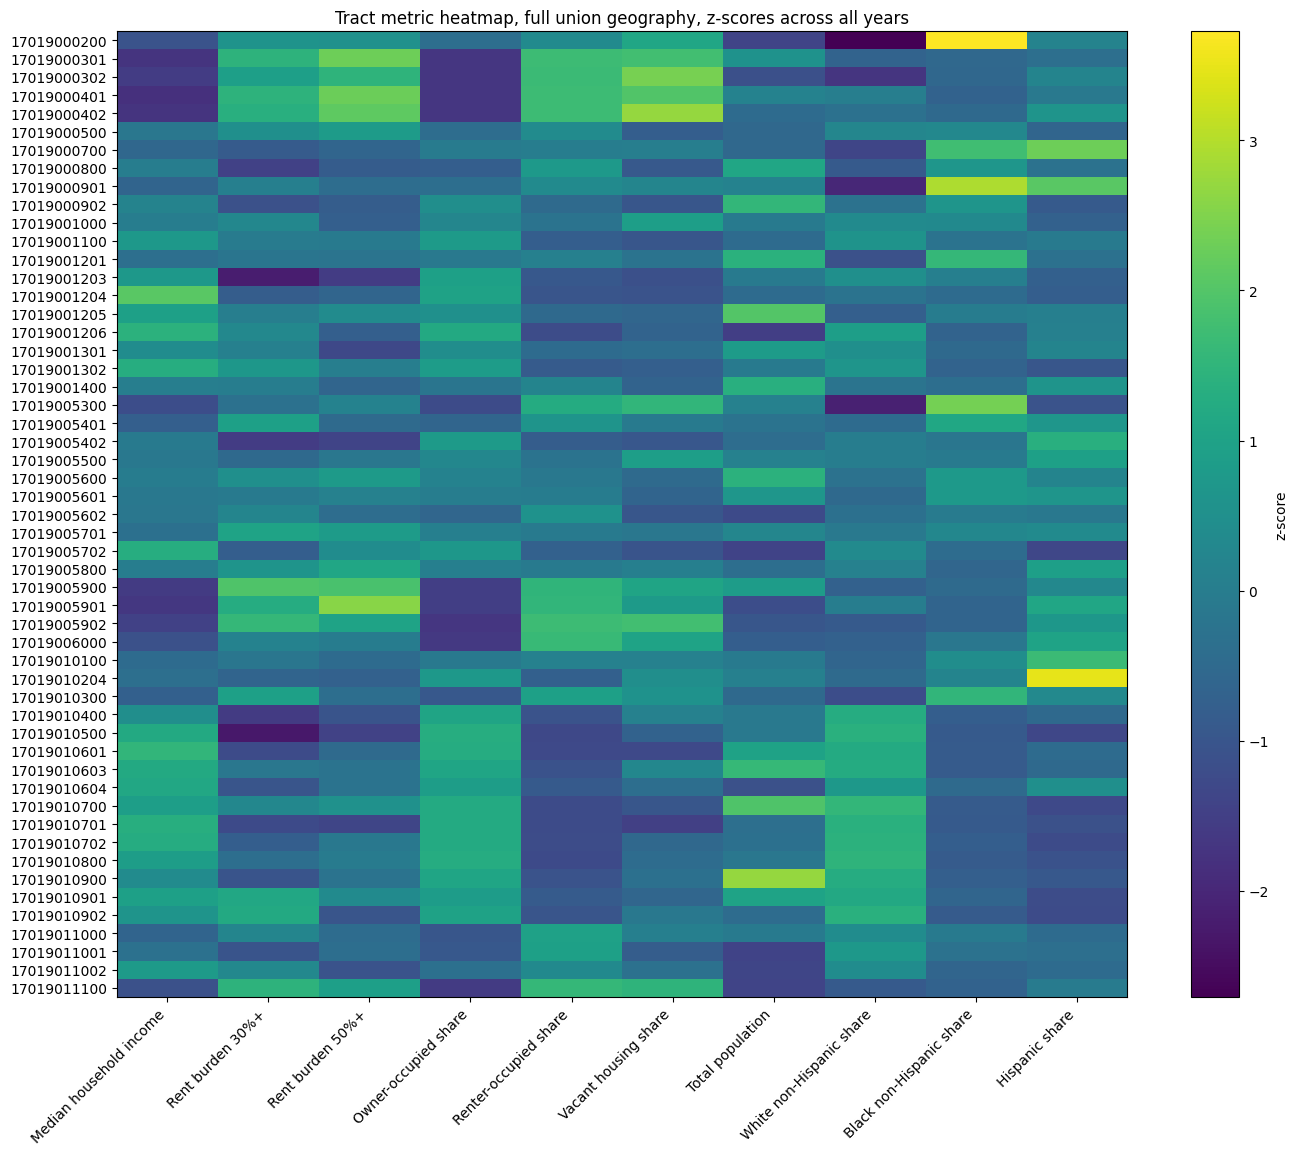

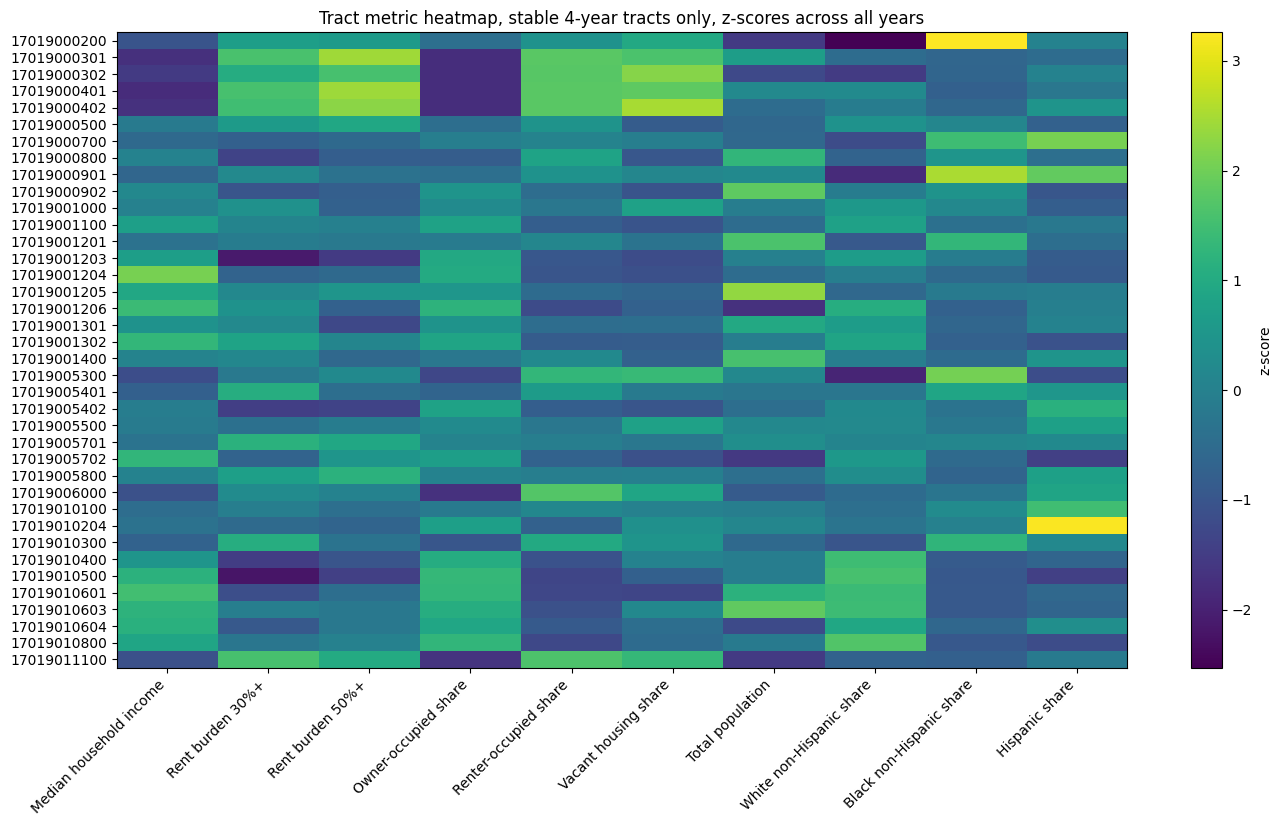

In [10]:
def zscore_with_guard(s: pd.Series) -> pd.Series:
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / std

heatmap_dir = PLOT_ROOT / 'tract_heatmaps'
heatmap_dir.mkdir(parents=True, exist_ok=True)

# Average across all years for each tract
tract_avg = acs_full.groupby('tract_geoid')[list(available_metrics.keys())].mean().reset_index()
tract_avg = tract_avg.set_index('tract_geoid')
tract_avg_z = tract_avg.apply(zscore_with_guard, axis=0)
tract_avg_z.to_csv(DATA_ROOT / 'tract_metric_heatmap_full_zscores.csv')

plt.figure(figsize=(14, max(8, len(tract_avg_z) * 0.22)))
plt.imshow(tract_avg_z.values, aspect='auto')
plt.xticks(range(len(tract_avg_z.columns)), [available_metrics[c] for c in tract_avg_z.columns], rotation=45, ha='right')
plt.yticks(range(len(tract_avg_z.index)), tract_avg_z.index)
plt.title('Tract metric heatmap, full union geography, z-scores across all years')
plt.colorbar(label='z-score')
plt.tight_layout()
plt.savefig(heatmap_dir / 'tract_metric_heatmap_full_refined.png', dpi=180)
plt.show()

# Stable-only heatmap
tract_avg_stable = acs_stable.groupby('tract_geoid')[list(available_metrics.keys())].mean().reset_index()
tract_avg_stable = tract_avg_stable.set_index('tract_geoid')
tract_avg_stable_z = tract_avg_stable.apply(zscore_with_guard, axis=0)
tract_avg_stable_z.to_csv(DATA_ROOT / 'tract_metric_heatmap_stable_zscores.csv')

plt.figure(figsize=(14, max(8, len(tract_avg_stable_z) * 0.22)))
plt.imshow(tract_avg_stable_z.values, aspect='auto')
plt.xticks(range(len(tract_avg_stable_z.columns)), [available_metrics[c] for c in tract_avg_stable_z.columns], rotation=45, ha='right')
plt.yticks(range(len(tract_avg_stable_z.index)), tract_avg_stable_z.index)
plt.title('Tract metric heatmap, stable 4-year tracts only, z-scores across all years')
plt.colorbar(label='z-score')
plt.tight_layout()
plt.savefig(heatmap_dir / 'tract_metric_heatmap_stable_refined.png', dpi=180)
plt.show()

## 10. Year-specific heatmaps

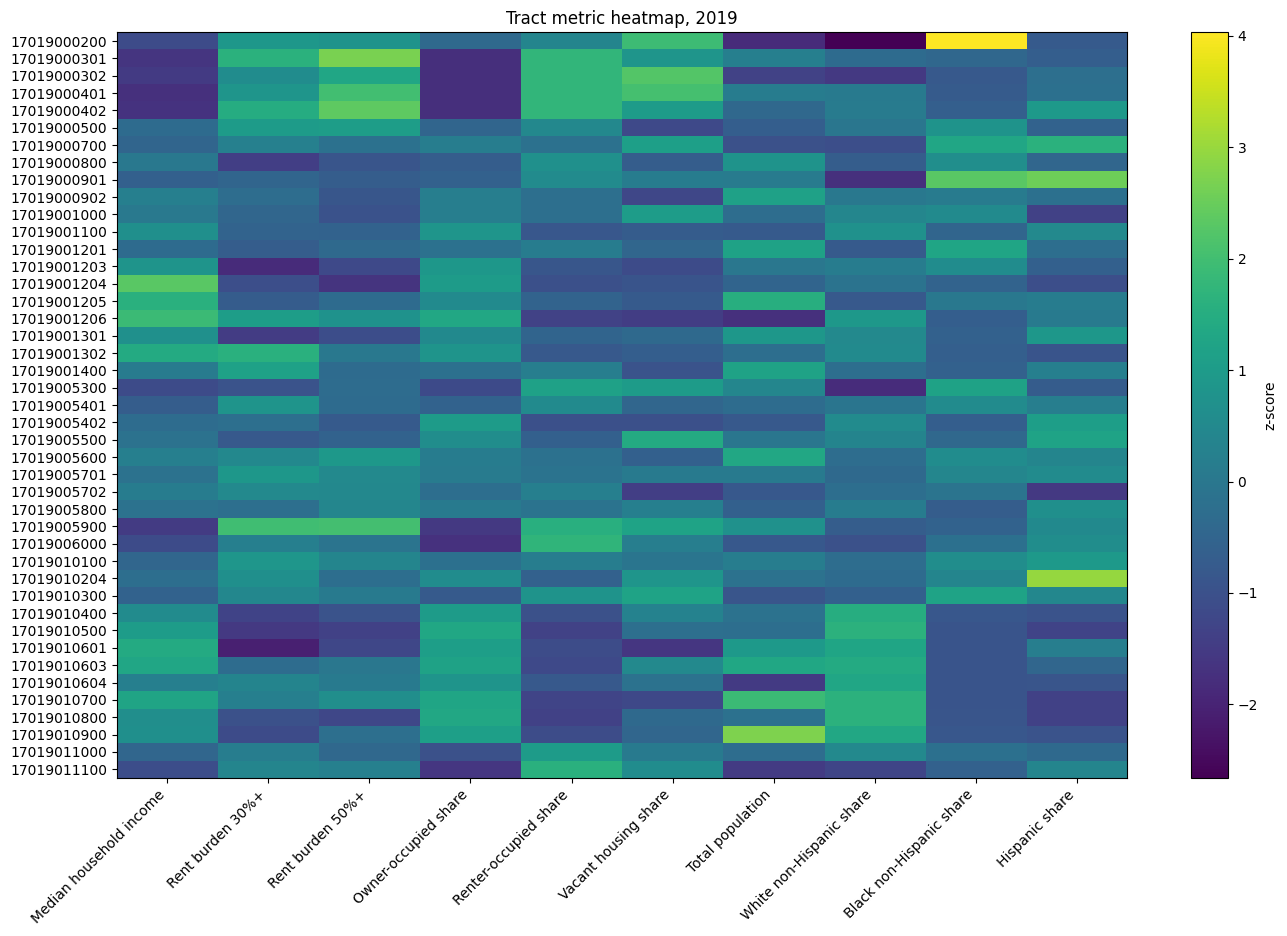

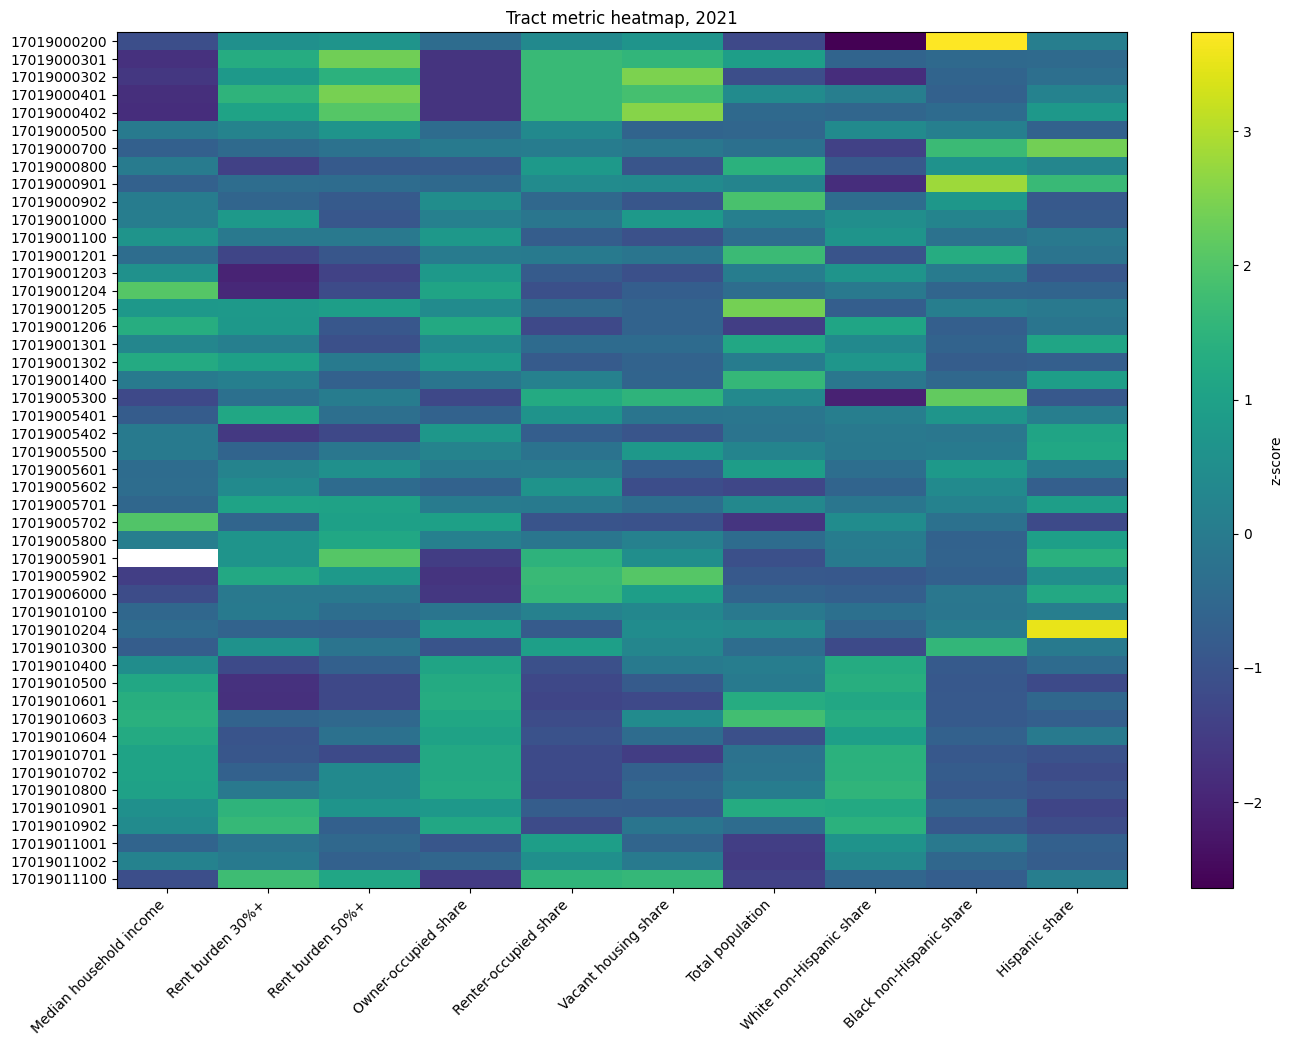

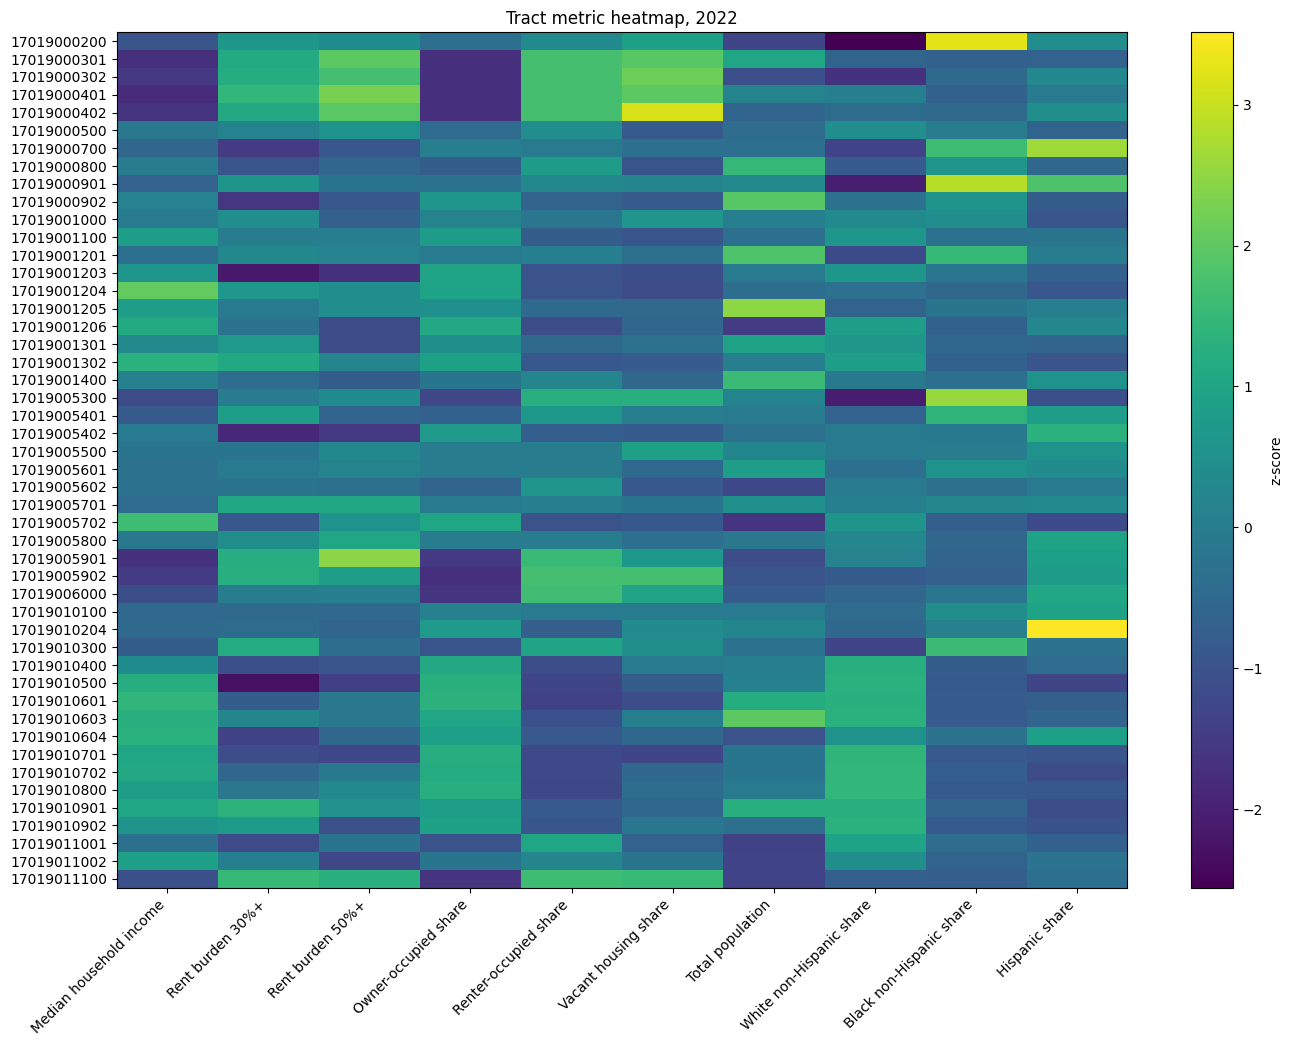

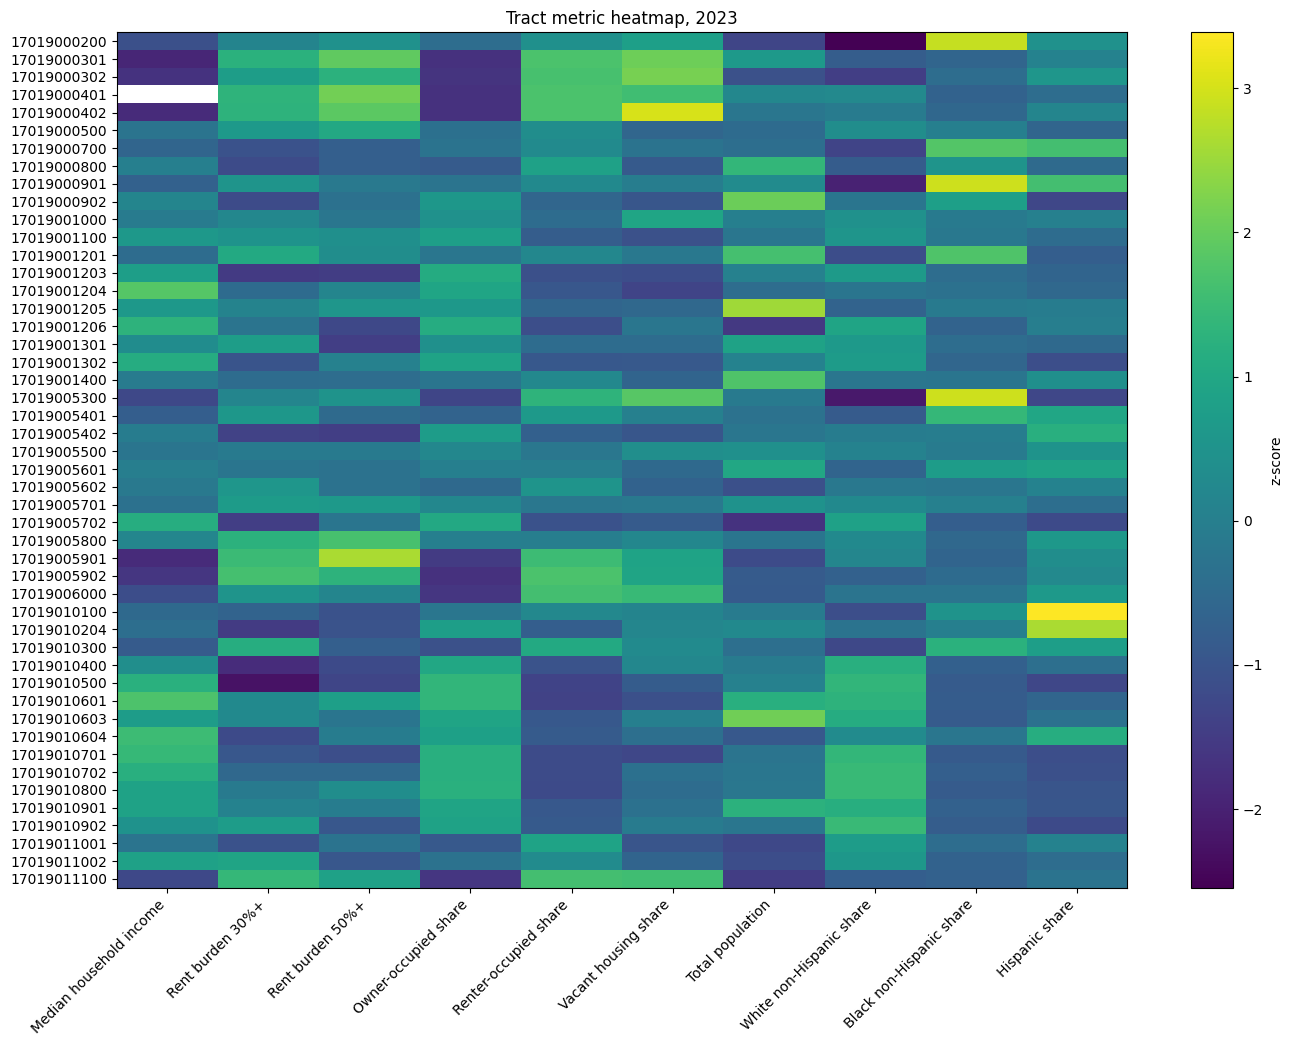

In [11]:
year_heatmap_dir = PLOT_ROOT / 'year_heatmaps'
year_heatmap_dir.mkdir(parents=True, exist_ok=True)

for year in sorted(acs_full['year'].dropna().unique()):
    year_df = acs_full[acs_full['year'] == year][['tract_geoid', *available_metrics.keys()]].copy()
    year_df = year_df.set_index('tract_geoid')
    year_df_z = year_df.apply(zscore_with_guard, axis=0)
    year_df_z.to_csv(DATA_ROOT / f'year_heatmap_zscores_{year}.csv')

    plt.figure(figsize=(14, max(8, len(year_df_z) * 0.22)))
    plt.imshow(year_df_z.values, aspect='auto')
    plt.xticks(range(len(year_df_z.columns)), [available_metrics[c] for c in year_df_z.columns], rotation=45, ha='right')
    plt.yticks(range(len(year_df_z.index)), year_df_z.index)
    plt.title(f'Tract metric heatmap, {year}')
    plt.colorbar(label='z-score')
    plt.tight_layout()
    plt.savefig(year_heatmap_dir / f'tract_metric_heatmap_{year}.png', dpi=180)
    plt.show()

## 11. Boxplots by year for the curated metric set

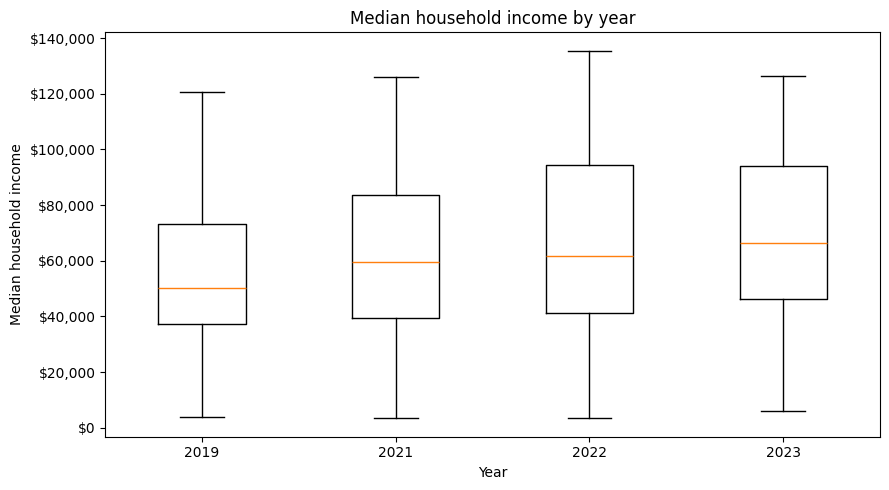

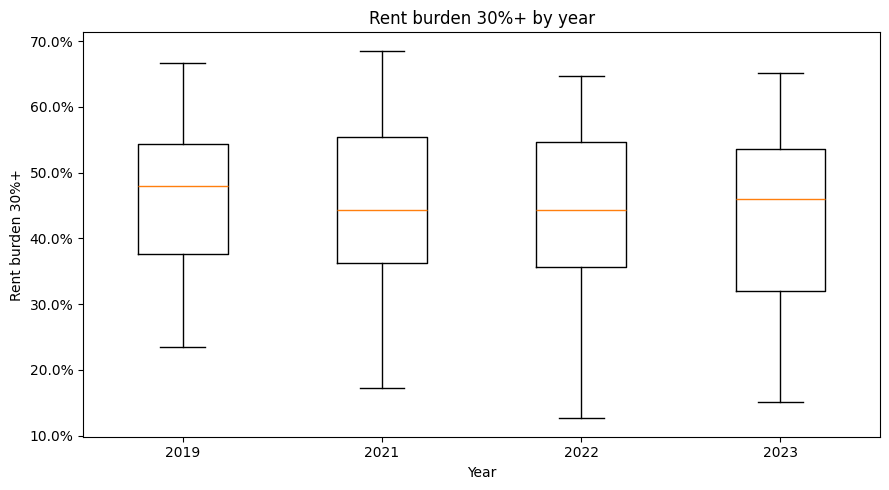

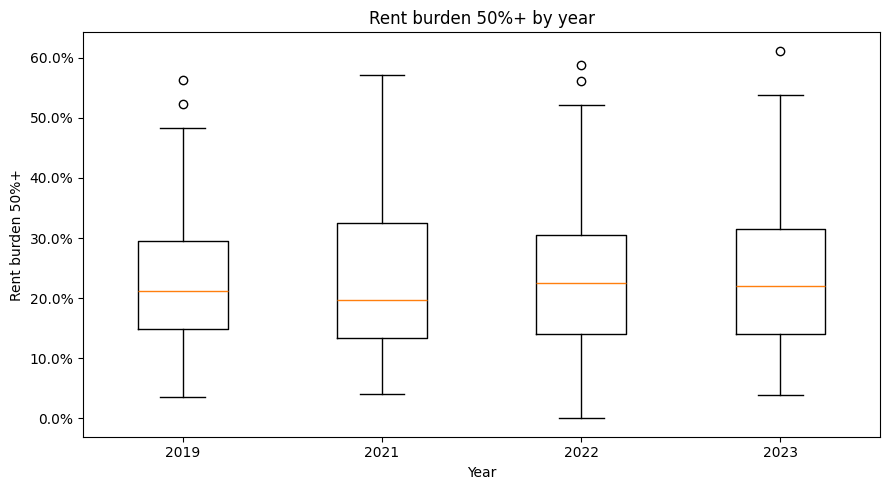

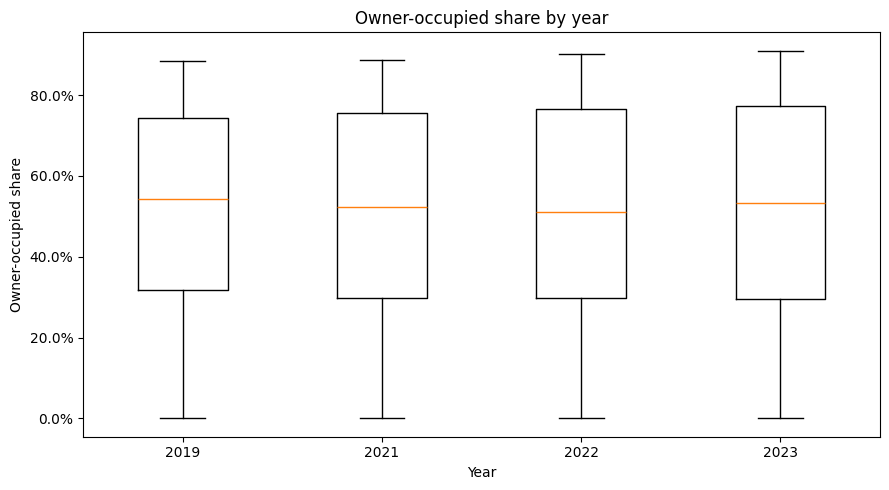

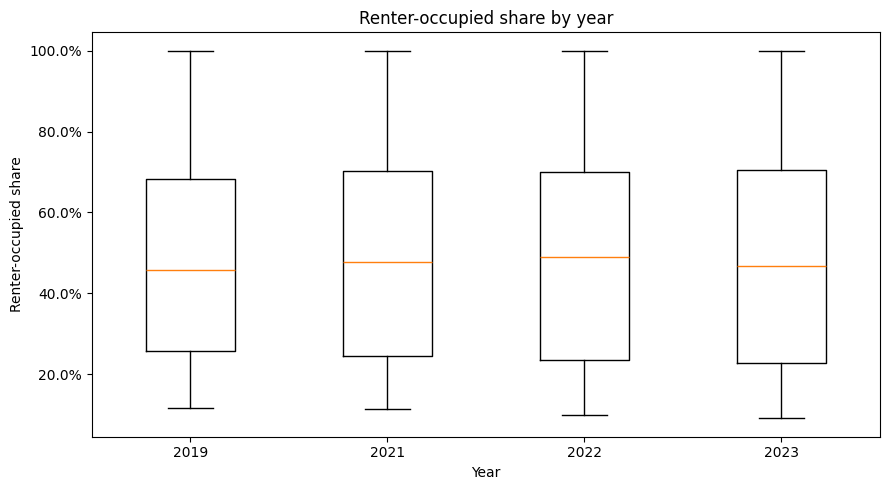

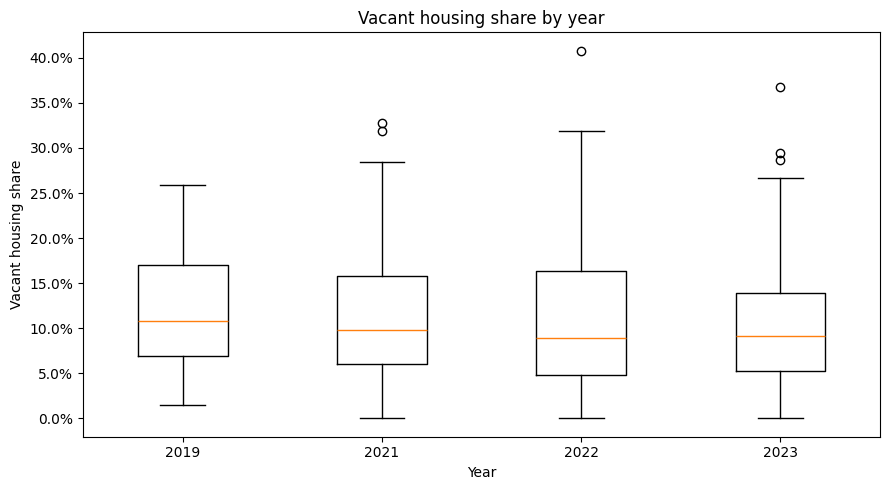

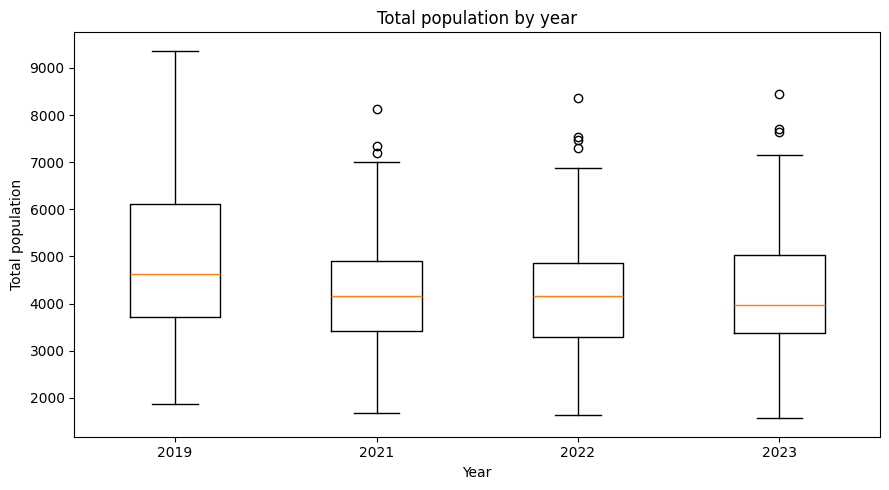

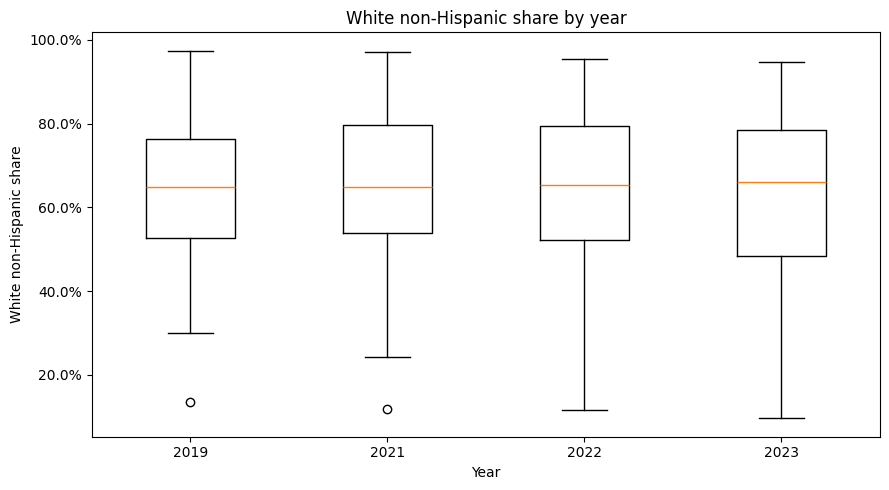

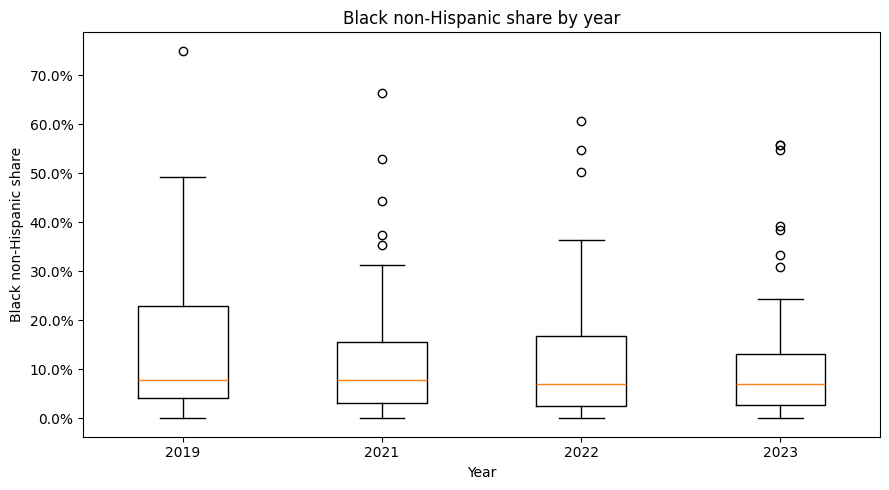

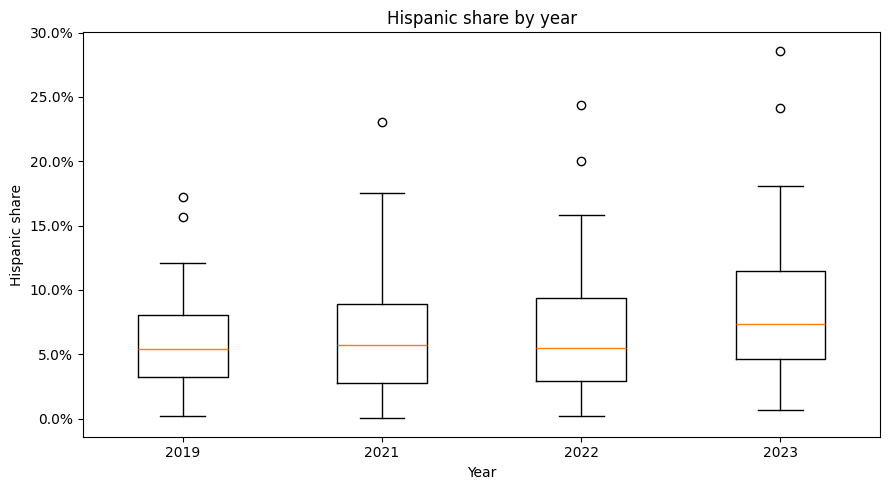

In [12]:
boxplot_dir = PLOT_ROOT / 'boxplots'
boxplot_dir.mkdir(parents=True, exist_ok=True)

currency_metrics = {'median_household_income'}
percent_metrics = {
    'pct_rent_burden_30_plus', 'pct_rent_burden_50_plus', 'pct_owner_occupied',
    'pct_renter_occupied', 'pct_vacant_housing_units', 'pct_white_non_hispanic',
    'pct_black_non_hispanic', 'pct_hispanic'
}

for metric_col, metric_label in available_metrics.items():
    plot_df = acs_full[['year', metric_col]].dropna().copy()
    if plot_df.empty:
        continue

    years = sorted(plot_df['year'].unique())
    series_list = [plot_df.loc[plot_df['year'] == y, metric_col].values for y in years]

    plt.figure(figsize=(9, 5))
    plt.boxplot(series_list, labels=years)
    plt.title(f'{metric_label} by year')
    plt.xlabel('Year')
    plt.ylabel(metric_label)
    if metric_col in currency_metrics:
        plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
    elif metric_col in percent_metrics:
        plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1f}%'))
    plt.tight_layout()
    plt.savefig(boxplot_dir / f'boxplot_{metric_col}.png', dpi=180)
    plt.show()

## 12. Trend plots using tract averages by year

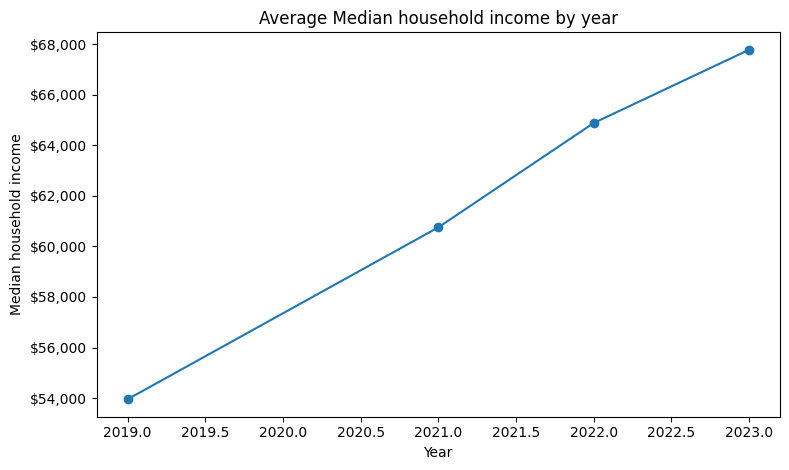

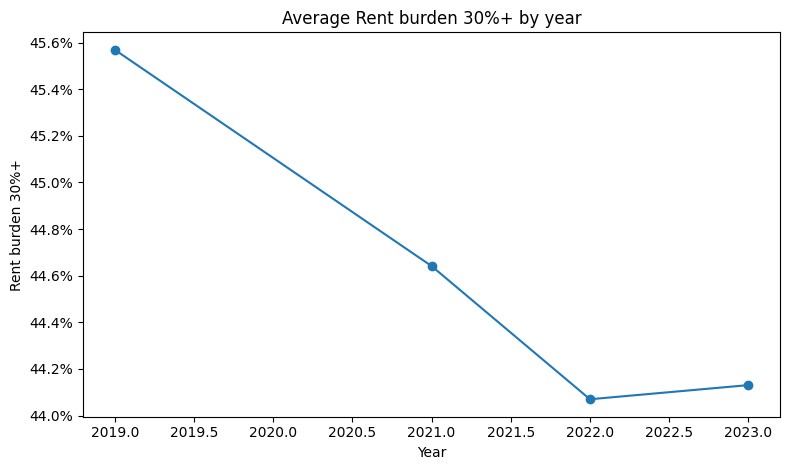

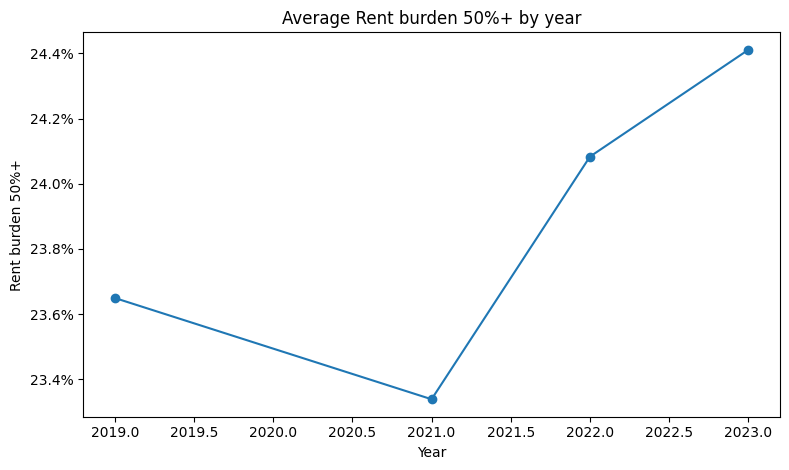

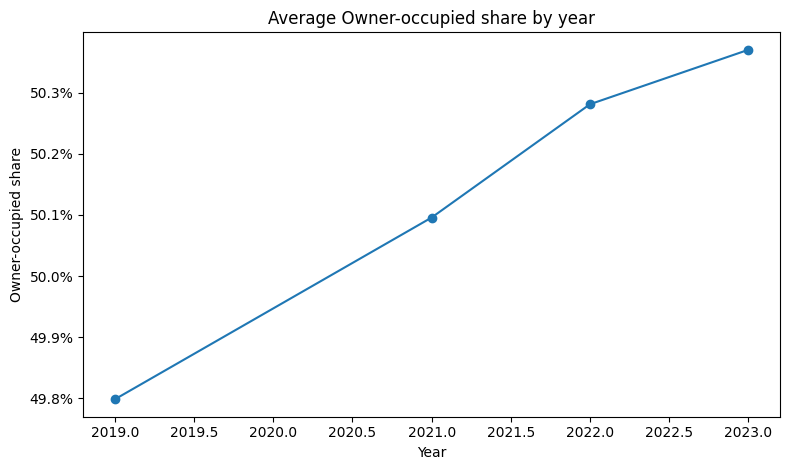

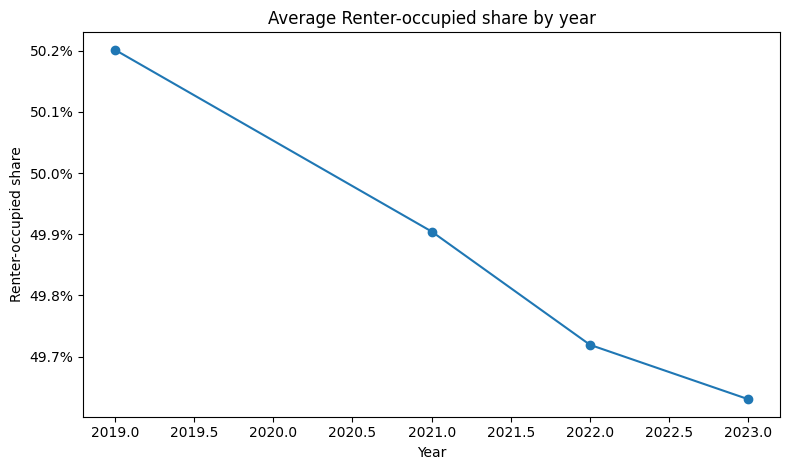

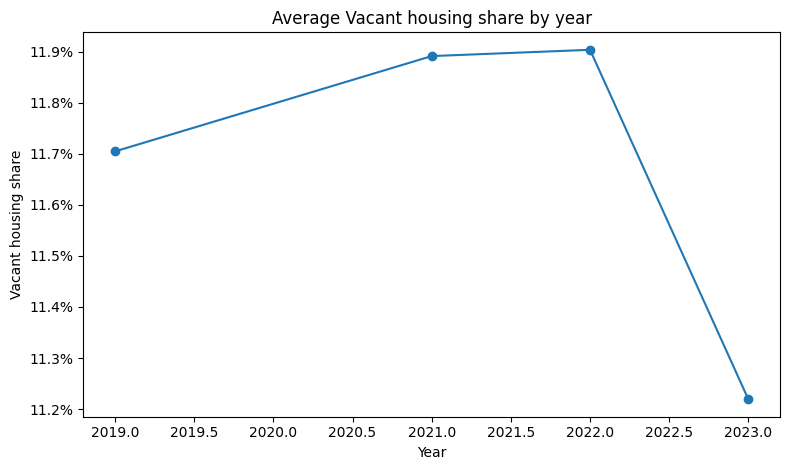

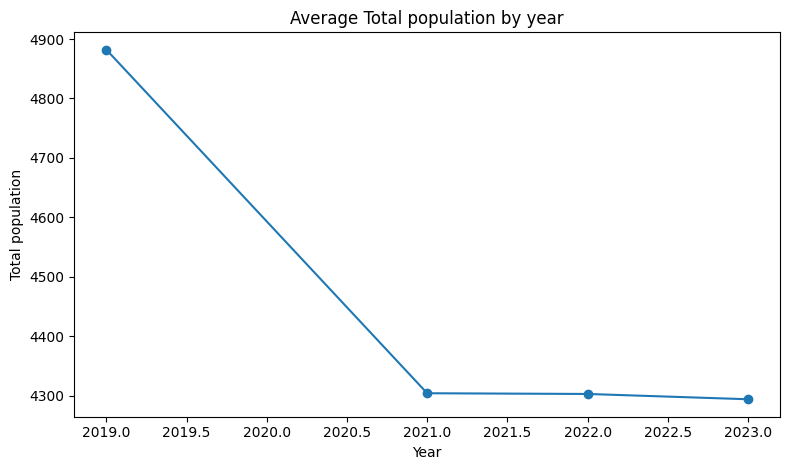

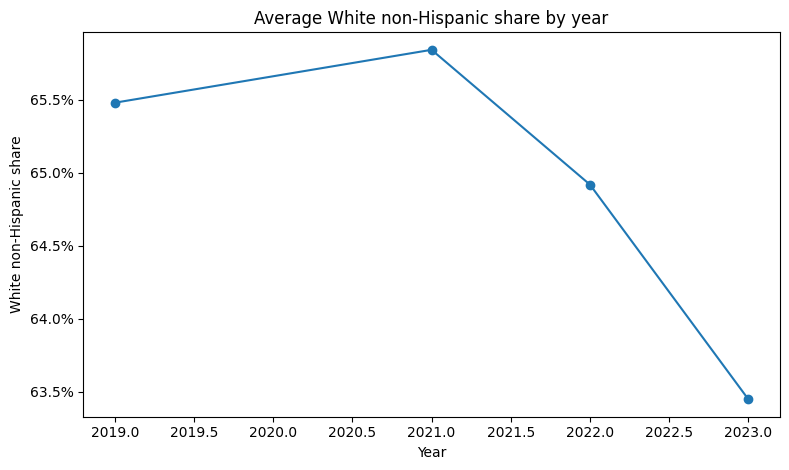

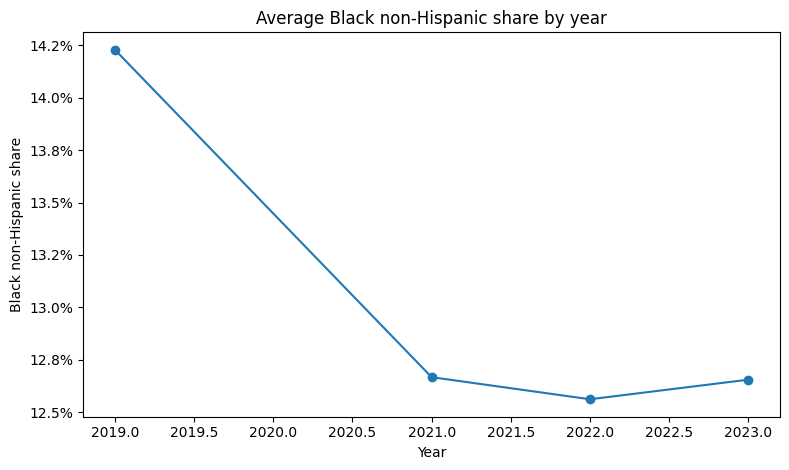

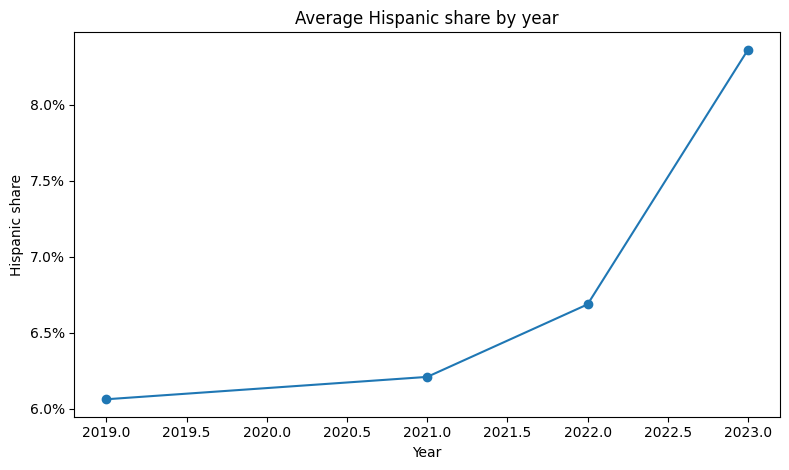

In [13]:
trend_dir = PLOT_ROOT / 'trends'
trend_dir.mkdir(parents=True, exist_ok=True)

yearly_means = acs_full.groupby('year')[list(available_metrics.keys())].mean().reset_index()
yearly_means.to_csv(SUMMARY_ROOT / 'visuals_yearly_metric_means.csv', index=False)

yearly_medians = acs_full.groupby('year')[list(available_metrics.keys())].median().reset_index()
yearly_medians.to_csv(SUMMARY_ROOT / 'visuals_yearly_metric_medians.csv', index=False)

for metric_col, metric_label in available_metrics.items():
    plt.figure(figsize=(8, 4.8))
    plt.plot(yearly_means['year'], yearly_means[metric_col], marker='o')
    plt.title(f'Average {metric_label} by year')
    plt.xlabel('Year')
    plt.ylabel(metric_label)
    if metric_col in currency_metrics:
        plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
    elif metric_col in percent_metrics:
        plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1f}%'))
    plt.tight_layout()
    plt.savefig(trend_dir / f'trend_{metric_col}.png', dpi=180)
    plt.show()

## 13. Top and bottom tract rankings by year

In [14]:
ranking_dir = PLOT_ROOT / 'rankings'
ranking_dir.mkdir(parents=True, exist_ok=True)
all_rankings = []

for year in sorted(acs_full['year'].dropna().unique()):
    year_df = acs_full[acs_full['year'] == year].copy()
    tract_name_col = 'tract_name_latest' if 'tract_name_latest' in year_df.columns else 'tract_geoid'

    for metric_col, metric_label in available_metrics.items():
        temp = year_df[['tract_geoid', tract_name_col, metric_col]].dropna().copy()
        if temp.empty:
            continue
        temp = temp.rename(columns={tract_name_col: 'tract_name', metric_col: 'metric_value'})
        temp['metric_column'] = metric_col
        temp['metric_label'] = metric_label
        temp['year'] = year
        temp['rank_desc'] = temp['metric_value'].rank(method='dense', ascending=False)
        temp['rank_asc'] = temp['metric_value'].rank(method='dense', ascending=True)
        all_rankings.append(temp)

rankings_df = pd.concat(all_rankings, ignore_index=True)
rankings_df.to_csv(SUMMARY_ROOT / 'visuals_rankings_long.csv', index=False)

# Export top/bottom 10 tables for each metric-year
rank_table_dir = DATA_ROOT / 'rankings'
rank_table_dir.mkdir(parents=True, exist_ok=True)
for (year, metric_col), grp in rankings_df.groupby(['year', 'metric_column']):
    grp.sort_values('metric_value', ascending=False).head(10).to_csv(rank_table_dir / f'top10_{metric_col}_{year}.csv', index=False)
    grp.sort_values('metric_value', ascending=True).head(10).to_csv(rank_table_dir / f'bottom10_{metric_col}_{year}.csv', index=False)

rankings_df.head()

,tract_geoid,tract_name,metric_value,metric_column,metric_label,year,rank_desc,rank_asc
0,17019000200,Census Tract 2; Champaign County; Illinois,21385.0,median_household_income,Median household income,2019,37.0,7.0
1,17019000301,Census Tract 3.01; Champaign County; Illinois,7099.0,median_household_income,Median household income,2019,41.0,3.0
2,17019000302,Census Tract 3.02; Champaign County; Illinois,10385.0,median_household_income,Median household income,2019,40.0,4.0
3,17019000401,Census Tract 4.01; Champaign County; Illinois,3864.0,median_household_income,Median household income,2019,43.0,1.0
4,17019000402,Census Tract 4.02; Champaign County; Illinois,5234.0,median_household_income,Median household income,2019,42.0,2.0


## 14. Year-over-year change tables for the stable tract subset

This uses only the stable tracts so that change over time is methodologically consistent.

In [15]:
change_tables = []
change_pairs = [(2019, 2021), (2021, 2022), (2022, 2023), (2019, 2023)]

stable_cols = ['tract_geoid', 'tract_name_latest', 'year', *available_metrics.keys()]
stable_base = acs_stable[[c for c in stable_cols if c in acs_stable.columns]].copy()
tract_name_col = 'tract_name_latest' if 'tract_name_latest' in stable_base.columns else 'tract_geoid'

for start_year, end_year in change_pairs:
    left = stable_base[stable_base['year'] == start_year].drop(columns='year').copy()
    right = stable_base[stable_base['year'] == end_year].drop(columns='year').copy()
    merged = left.merge(right, on=['tract_geoid', tract_name_col], suffixes=(f'_{start_year}', f'_{end_year}'))

    for metric_col, metric_label in available_metrics.items():
        if f'{metric_col}_{start_year}' not in merged.columns or f'{metric_col}_{end_year}' not in merged.columns:
            continue
        temp = merged[['tract_geoid', tract_name_col, f'{metric_col}_{start_year}', f'{metric_col}_{end_year}']].copy()
        temp = temp.rename(columns={
            tract_name_col: 'tract_name',
            f'{metric_col}_{start_year}': 'value_start',
            f'{metric_col}_{end_year}': 'value_end',
        })
        temp['metric_column'] = metric_col
        temp['metric_label'] = metric_label
        temp['start_year'] = start_year
        temp['end_year'] = end_year
        temp['absolute_change'] = temp['value_end'] - temp['value_start']
        with np.errstate(divide='ignore', invalid='ignore'):
            temp['pct_change'] = np.where(
                temp['value_start'].notna() & (temp['value_start'] != 0),
                (temp['value_end'] - temp['value_start']) / temp['value_start'] * 100,
                np.nan
            )
        change_tables.append(temp)

changes_long = pd.concat(change_tables, ignore_index=True)
changes_long.to_csv(CHANGE_ROOT / 'stable_tract_changes_long.csv', index=False)

change_summary = (
    changes_long.groupby(['start_year', 'end_year', 'metric_column', 'metric_label'])['absolute_change']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)
change_summary.to_csv(CHANGE_ROOT / 'stable_tract_change_summary.csv', index=False)
change_summary.head(20)

,start_year,end_year,metric_column,metric_label,count,mean,median,min,max
0,2019,2021,median_household_income,Median household income,38,6533.157895,3366.500,-14530.00,65535.00
1,2019,2021,pct_black_non_hispanic,Black non-Hispanic share,38,-0.913947,-0.350,-12.91,12.25
2,2019,2021,pct_hispanic,Hispanic share,38,0.578947,0.275,-3.21,5.81
3,2019,2021,pct_owner_occupied,Owner-occupied share,38,1.045263,0.000,-10.97,36.07
4,2019,2021,pct_rent_burden_30_plus,Rent burden 30%+,38,-1.818421,-2.610,-20.31,19.00
5,2019,2021,pct_rent_burden_50_plus,Rent burden 50%+,38,0.276053,-0.505,-22.05,20.03
6,2019,2021,pct_renter_occupied,Renter-occupied share,38,-1.045263,0.000,-36.07,10.97
7,2019,2021,pct_vacant_housing_units,Vacant housing share,38,0.653158,0.165,-7.96,14.67
8,2019,2021,pct_white_non_hispanic,White non-Hispanic share,38,-0.875526,-0.980,-13.03,14.41
9,2019,2021,total_population,Total population,38,-96.236842,-141.000,-1874.00,726.00


## 15. Biggest movers for each change window

In [16]:
movers_dir = CHANGE_ROOT / 'movers'
movers_dir.mkdir(parents=True, exist_ok=True)

for (start_year, end_year, metric_col), grp in changes_long.groupby(['start_year', 'end_year', 'metric_column']):
    grp.sort_values('absolute_change', ascending=False).head(10).to_csv(
        movers_dir / f'top_gainers_{metric_col}_{start_year}_{end_year}.csv', index=False
    )
    grp.sort_values('absolute_change', ascending=True).head(10).to_csv(
        movers_dir / f'top_decliners_{metric_col}_{start_year}_{end_year}.csv', index=False
    )

changes_long.head()

,tract_geoid,tract_name,value_start,value_end,metric_column,metric_label,start_year,end_year,absolute_change,pct_change
0,17019000200,Census Tract 2; Champaign County; Illinois,21385.0,25531.0,median_household_income,Median household income,2019,2021,4146.0,19.387421
1,17019000301,Census Tract 3.01; Champaign County; Illinois,7099.0,5512.0,median_household_income,Median household income,2019,2021,-1587.0,-22.355261
2,17019000302,Census Tract 3.02; Champaign County; Illinois,10385.0,9771.0,median_household_income,Median household income,2019,2021,-614.0,-5.912374
3,17019000401,Census Tract 4.01; Champaign County; Illinois,3864.0,4476.0,median_household_income,Median household income,2019,2021,612.0,15.838509
4,17019000402,Census Tract 4.02; Champaign County; Illinois,5234.0,3416.0,median_household_income,Median household income,2019,2021,-1818.0,-34.734429


## 16. Change plots for tract averages

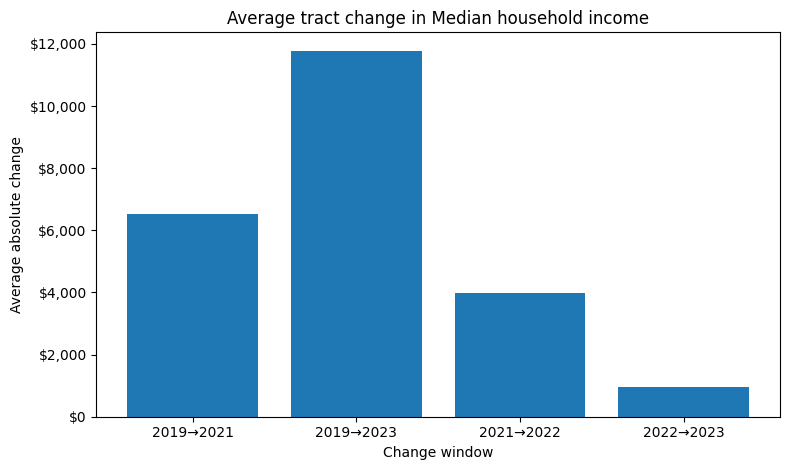

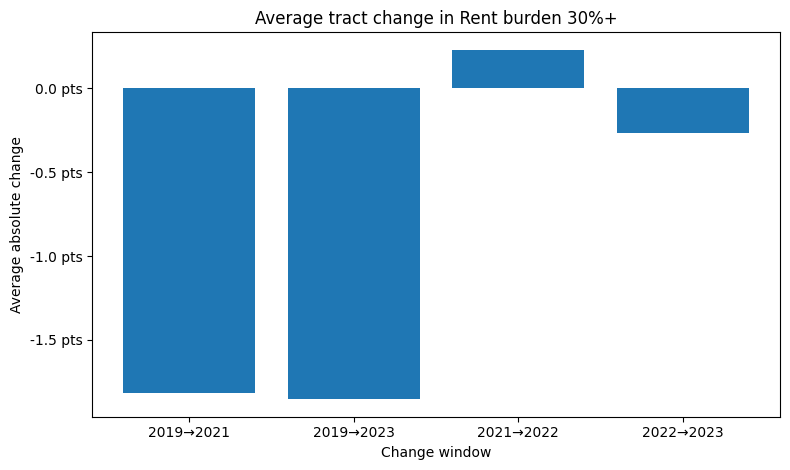

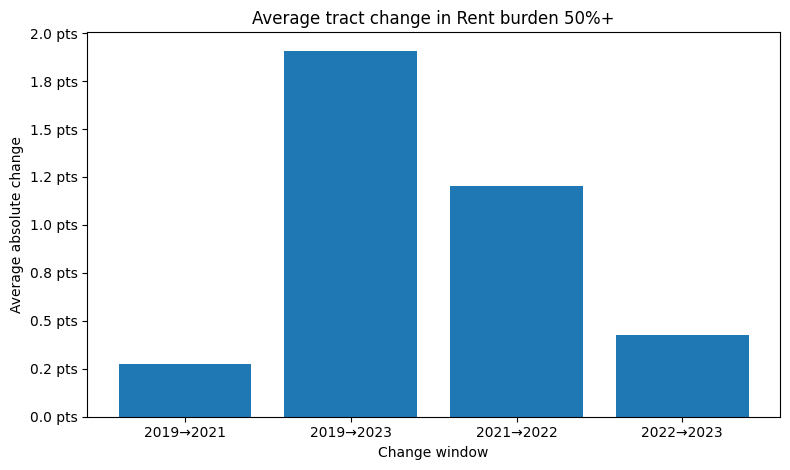

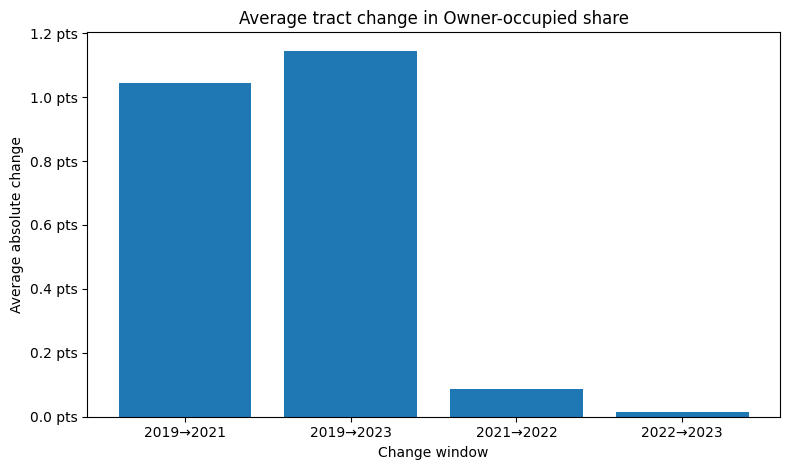

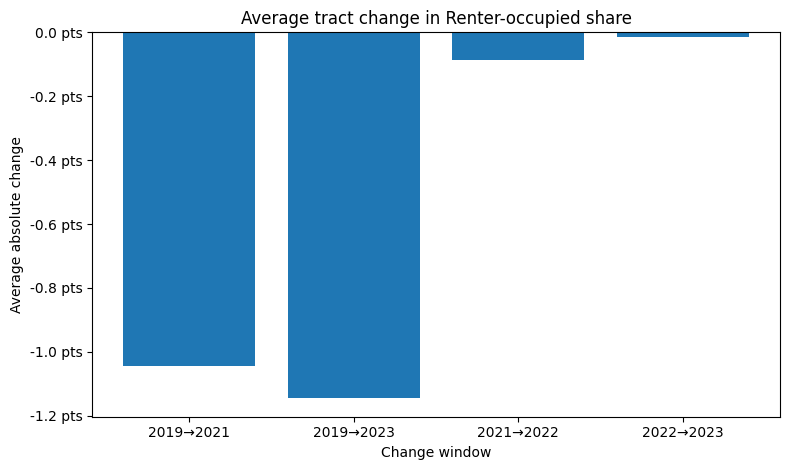

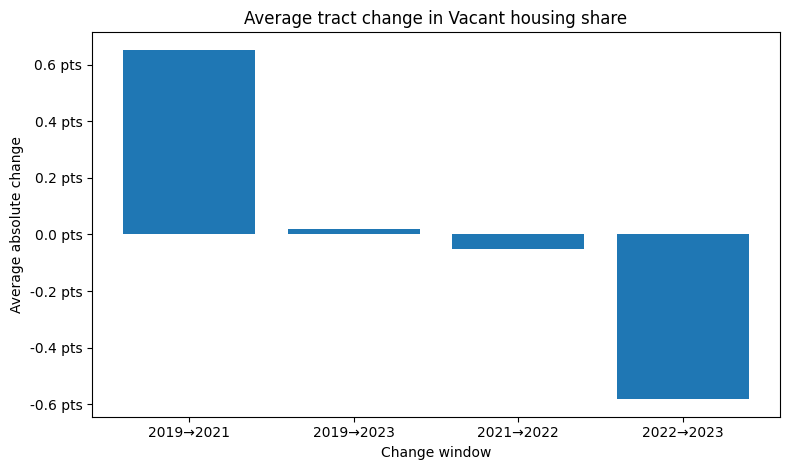

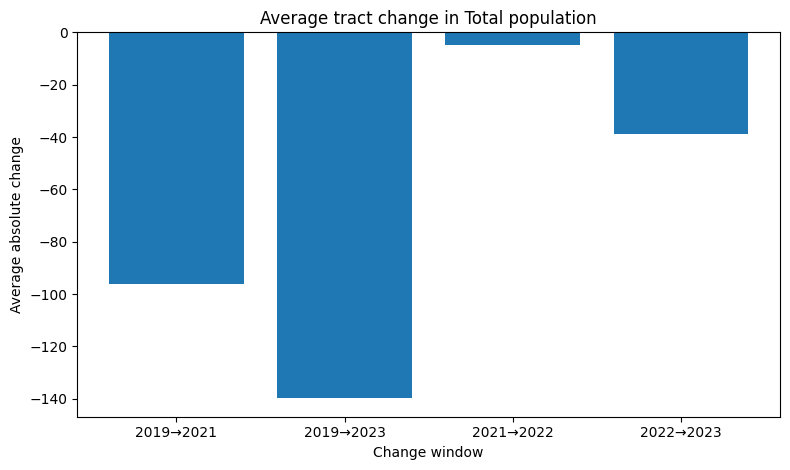

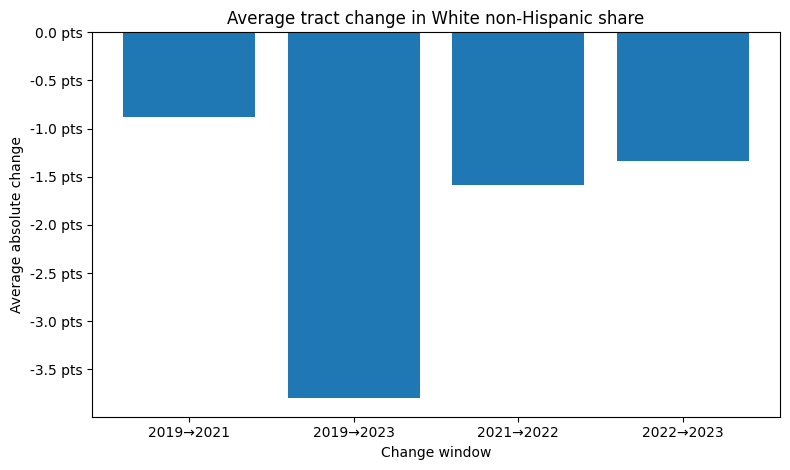

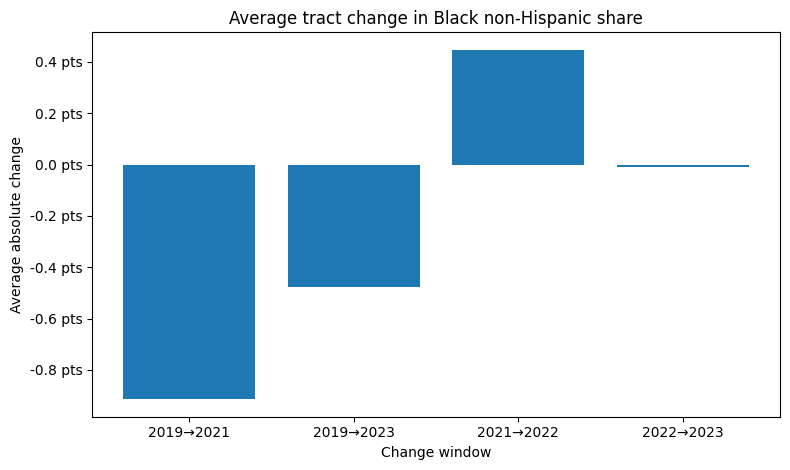

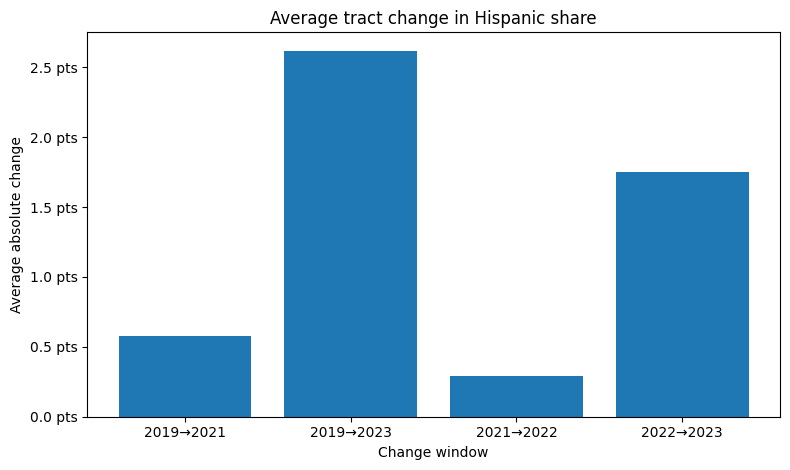

In [17]:
change_plot_dir = PLOT_ROOT / 'change_plots'
change_plot_dir.mkdir(parents=True, exist_ok=True)

for metric_col, metric_label in available_metrics.items():
    sub = changes_long[changes_long['metric_column'] == metric_col].copy()
    if sub.empty:
        continue
    sub['change_window'] = sub['start_year'].astype(str) + '→' + sub['end_year'].astype(str)
    summary = sub.groupby('change_window')['absolute_change'].mean().reset_index(name='avg_absolute_change')

    plt.figure(figsize=(8, 4.8))
    plt.bar(summary['change_window'], summary['avg_absolute_change'])
    plt.title(f'Average tract change in {metric_label}')
    plt.xlabel('Change window')
    plt.ylabel('Average absolute change')
    if metric_col in currency_metrics:
        plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
    elif metric_col in percent_metrics:
        plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1f} pts'))
    plt.tight_layout()
    plt.savefig(change_plot_dir / f'avg_change_{metric_col}.png', dpi=180)
    plt.show()

## 17. Choropleth-ready export tables

These files are meant to be joined to a tract shapefile or tract GeoJSON later.
They use `tract_geoid` as the join key.

In [18]:
choropleth_exports = []
for year in sorted(acs_full['year'].dropna().unique()):
    year_df = acs_full[acs_full['year'] == year].copy()
    export_cols = ['tract_geoid'] + [c for c in ['tract_name_latest', 'tract_name_canonical', 'county_name', 'state_name'] if c in year_df.columns] + list(available_metrics.keys())
    export_df = year_df[export_cols].copy()
    export_df.to_csv(MAP_INPUT_ROOT / f'choropleth_ready_{year}.csv', index=False)
    choropleth_exports.append({'year': year, 'row_count': len(export_df), 'file_name': f'choropleth_ready_{year}.csv'})

choropleth_export_manifest = pd.DataFrame(choropleth_exports)
choropleth_export_manifest.to_csv(MAP_INPUT_ROOT / 'choropleth_export_manifest.csv', index=False)
choropleth_export_manifest

,year,row_count,file_name
0,2019,43,choropleth_ready_2019.csv
1,2021,48,choropleth_ready_2021.csv
2,2022,48,choropleth_ready_2022.csv
3,2023,48,choropleth_ready_2023.csv


## 18. Optional local tract map generation

This section is optional.
It only runs if you already have a local tract geometry file, such as a `.shp`, `.geojson`, or `.gpkg`.

Set `TRACT_GEOMETRY_PATH` to your local file path if you want the notebook to generate actual choropleth maps.
Otherwise this cell will skip safely and you can still use the choropleth-ready CSVs in Tableau, QGIS, ArcGIS, or Python later.

In [19]:
TRACT_GEOMETRY_PATH = None
# Example:
# TRACT_GEOMETRY_PATH = PROJECT_ROOT / 'data' / 'raw' / 'geo' / 'champaign_tracts.geojson'

In [20]:
try:
    import geopandas as gpd
except Exception:
    gpd = None

if TRACT_GEOMETRY_PATH and gpd is not None and Path(TRACT_GEOMETRY_PATH).exists():
    geo = gpd.read_file(TRACT_GEOMETRY_PATH)

    # Try common GEOID fields.
    geoid_candidates = ['GEOID', 'geoid', 'tract_geoid', 'GEOIDFQ', 'geoid10', 'GEOID10']
    geoid_col = next((c for c in geoid_candidates if c in geo.columns), None)
    if geoid_col is None:
        raise ValueError(f'No GEOID-like column found in geometry file. Columns: {list(geo.columns)}')

    geo['tract_geoid'] = geo[geoid_col].astype(str).str[-11:]

    for year in sorted(acs_full['year'].dropna().unique()):
        year_df = pd.read_csv(MAP_INPUT_ROOT / f'choropleth_ready_{year}.csv', dtype={'tract_geoid': str})
        gdf = geo.merge(year_df, on='tract_geoid', how='left')

        for metric_col, metric_label in available_metrics.items():
            if metric_col not in gdf.columns:
                continue
            ax = gdf.plot(column=metric_col, legend=True, figsize=(10, 8), missing_kwds={'color': 'lightgrey'})
            ax.set_title(f'{metric_label}, {year}')
            ax.set_axis_off()
            fig = ax.get_figure()
            fig.tight_layout()
            fig.savefig(OPTIONAL_MAP_PLOT_ROOT / f'map_{metric_col}_{year}.png', dpi=180)
            plt.show()
else:
    print('Skipping local choropleth generation.')
    print('Reason: no geometry path set, geometry file not found, or geopandas not installed.')
    print('Your choropleth-ready CSV exports are already saved under:')
    print(MAP_INPUT_ROOT)

Skipping local choropleth generation.
Reason: no geometry path set, geometry file not found, or geopandas not installed.
Your choropleth-ready CSV exports are already saved under:
d:\Projects\Community-Pulse\outputs\acs\analysis\maps\map_inputs


## 19. Final output checklist

In [21]:
from IPython.display import display

output_manifest = []
for folder_name in ['summary', 'data', 'plots', 'changes']:
    folder = VISUALS_ROOT / folder_name
    if folder.exists():
        for file in sorted(folder.rglob('*')):
            if file.is_file():
                output_manifest.append({
                    'section': folder_name,
                    'relative_path': str(file.relative_to(OUTPUT_ROOT))
                })

for file in sorted(MAP_ROOT.rglob('*')):
    if file.is_file():
        output_manifest.append({
            'section': 'maps',
            'relative_path': str(file.relative_to(OUTPUT_ROOT))
        })

manifest_df = pd.DataFrame(output_manifest)
manifest_df.to_csv(SUMMARY_ROOT / 'visuals_output_manifest.csv', index=False)
display(manifest_df.head(50))
print('Total output files:', len(manifest_df))

,section,relative_path
0,summary,visuals\summary\visuals_metric_inventory.csv
1,summary,visuals\summary\visuals_missing_profile_by_yea...
2,summary,visuals\summary\visuals_numeric_summary_by_yea...
3,summary,visuals\summary\visuals_rankings_long.csv
4,summary,visuals\summary\visuals_run_summary.csv
5,summary,visuals\summary\visuals_yearly_metric_means.csv
6,summary,visuals\summary\visuals_yearly_metric_medians.csv
7,data,visuals\data\acs_visuals_full.csv
8,data,visuals\data\acs_visuals_long_full.csv
9,data,visuals\data\acs_visuals_long_stable.csv


Total output files: 220
